# Universe Analysis — testing additions/removals for the allocator

**Purpose.** The current sweep shows the PPO allocator's Sharpe ceiling is ~ EqualWeight on the existing 10 ETFs. One plausible lever for making the policy more *reactive* (less collapsed to equal-weight) is to change the **universe**: prune redundant assets, and/or add tickers from asset classes that aren't covered.

**Hard constraint.** The pipeline starts at `download_start_date = 2007-05-01`. Any candidate ticker whose **first available trade date is later than that** can't be added without truncating the training window. This notebook checks inception dates first, then runs the analysis.

**What it produces.**
1. Inception-date table for the current universe + every candidate (who qualifies for 2007-05-01).
2. Correlation matrix of the current universe → identifies any redundant pairs (`corr > 0.85`).
3. Asset-class coverage map — what's already in vs what's missing.
4. **Marginal diversification contribution** of each qualifying candidate, measured by:
   - the candidate's average correlation with the current universe,
   - the change in cross-sectional return dispersion,
   - the change in *effective number of independent assets* (participation ratio of the correlation matrix's eigenvalues).
5. A ranked recommendation of which tickers to add/drop.

**Important reality check.** The model collapses to equal-weight largely because cross-sectional dispersion is small relative to noise at daily frequency — this is *structural*, not just a universe issue. The literature (Kashif & Slepaczuk 2025; Liang et al. 2018; Jiang et al. 2017) suggests adding asset-class diversity helps **at the margin**, not transformatively. Expect this analysis to surface modest, defensible additions — not a silver bullet.

In [17]:
import json
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.max_rows", 100)

CONFIG_PATH = Path("config.json")
cfg = json.load(open(CONFIG_PATH))
CURRENT_TICKERS = cfg["data"]["ticker_list"]
TARGET_START = pd.Timestamp(cfg["data"]["download_start_date"])
print("Current universe (10):", CURRENT_TICKERS)
print("Target download_start_date:", TARGET_START.date())

Current universe (10): ['IVE', 'QQQ', 'TLT', 'SHY', 'LQD', 'HYG', 'GLD', 'EEM', 'VNQ', 'XLE']
Target download_start_date: 2007-08-01


## 1. Candidate tickers + asset-class taxonomy

Built from theory (which classes meaningfully decorrelate from US equity / bonds / gold). For each ticker we record the asset class it represents so we can later check **coverage gaps**.

Categories the current 10 already cover: US Large Value (IVE), US Large Growth (QQQ), Long Treasuries (TLT), Short Treasuries (SHY), IG Credit (LQD), High Yield (HYG), Gold (GLD), Emerging Markets (EEM), US Real Estate (VNQ), US Energy Sector (XLE).

In [18]:
ASSET_CLASS = {
    # --- Current universe (already in) ---
    "IVE": "US Large Value",
    "QQQ": "US Large Growth",
    "TLT": "US Long Treasuries",
    "SHY": "US Short Treasuries",
    "LQD": "Investment Grade Credit",
    "HYG": "High Yield Credit",
    "GLD": "Gold",
    "EEM": "Emerging Markets Equity",
    "VNQ": "US Real Estate",
    "XLE": "US Energy Sector",

    # --- Candidate additions, grouped by gap they would close ---
    # Developed international equity (the only equity class NOT in the current 10)
    "EFA": "Developed International Equity",
    "VEA": "Developed International Equity",

    # Broad commodities (current 10 only has Energy XLE — missing agri/metals/broad)
    "DBC": "Broad Commodities",
    "DBA": "Agricultural Commodities",
    "USO": "Crude Oil",
    "SLV": "Silver",

    # Inflation-linked bonds (current 10 has nominal bonds only)
    "TIP": "Inflation-Linked Treasuries",

    # US small/total market
    "IWM": "US Small-Cap",
    "VTI": "US Total Market",
    "DIA": "US Large-Cap Blue Chip",
    "SPY": "US Large-Cap Broad",

    # US defensive sectors (low-beta, regime-shifting equity)
    "XLU": "US Utilities (Defensive)",
    "XLP": "US Consumer Staples (Defensive)",
    "XLV": "US Healthcare (Defensive)",

    # US cyclical sectors (covered universe completeness)
    "XLF": "US Financials",
    "XLK": "US Technology",
    "XLI": "US Industrials",
    "XLY": "US Consumer Discretionary",
    "XLB": "US Materials",

    # Currencies
    "UUP": "US Dollar Bullish",
    "FXE": "Euro",
    "FXY": "Japanese Yen",

    # Thematic / alternative-structure equity (non-crypto alternatives that qualify for 2007-05-01)
    "PHO": "Water Utilities (Thematic)",
    "GDX": "Gold Miners (Equity + Gold beta)",
    "PSP": "Listed Private Equity Proxy",

    # Preferred / hybrid
    "PFF": "Preferred Stock",
}

CANDIDATES = [t for t in ASSET_CLASS if t not in CURRENT_TICKERS]
ALL_TICKERS = CURRENT_TICKERS + CANDIDATES
print(f"Current: {len(CURRENT_TICKERS)} tickers — Candidates: {len(CANDIDATES)} tickers — Total to check: {len(ALL_TICKERS)}")

Current: 10 tickers — Candidates: 26 tickers — Total to check: 36


## 2. Inception-date check

For each ticker, find the **first available trade date** on Yahoo Finance. A ticker *qualifies* for the current pipeline if that date is **on or before `2007-05-01`** (the configured `download_start_date`).

In [19]:
def first_available_date(ticker):
    """Returns the first trade date on Yahoo (UTC-naive Timestamp), or None."""
    try:
        h = yf.Ticker(ticker).history(period="max", auto_adjust=True)
        if h.empty:
            return None
        d = h.index[0]
        return d.tz_localize(None) if getattr(d, "tz", None) else d
    except Exception as e:
        print(f"  ! {ticker}: {e}")
        return None

rows = []
for t in ALL_TICKERS:
    fd = first_available_date(t)
    qualifies = (fd is not None) and (fd <= TARGET_START)
    rows.append({
        "ticker": t,
        "first_date": fd.date() if fd is not None else None,
        "qualifies": qualifies,
        "asset_class": ASSET_CLASS.get(t, "?"),
        "is_current": t in CURRENT_TICKERS,
    })

inception = pd.DataFrame(rows).sort_values(
    ["is_current", "qualifies", "first_date"],
    ascending=[False, False, True],
).reset_index(drop=True)
inception

,ticker,first_date,qualifies,asset_class,is_current
0,XLE,1998-12-22,True,US Energy Sector,True
1,QQQ,1999-03-10,True,US Large Growth,True
2,IVE,2000-05-26,True,US Large Value,True
3,TLT,2002-07-30,True,US Long Treasuries,True
4,SHY,2002-07-30,True,US Short Treasuries,True
5,LQD,2002-07-30,True,Investment Grade Credit,True
6,EEM,2003-04-14,True,Emerging Markets Equity,True
7,VNQ,2004-09-29,True,US Real Estate,True
8,GLD,2004-11-18,True,Gold,True
9,HYG,2007-04-11,True,High Yield Credit,True


In [20]:
print("=== Current universe — sanity check (should all qualify) ===")
print(inception[inception["is_current"]][["ticker","first_date","qualifies","asset_class"]].to_string(index=False))

qualifying = inception[(~inception["is_current"]) & (inception["qualifies"])]
disqualified = inception[(~inception["is_current"]) & (~inception["qualifies"])]

print(f"\n=== Candidates that QUALIFY for 2007-05-01 ({len(qualifying)}) ===")
print(qualifying[["ticker","first_date","asset_class"]].to_string(index=False))

print(f"\n=== Candidates DISQUALIFIED (too young) ({len(disqualified)}) ===")
print(disqualified[["ticker","first_date","asset_class"]].to_string(index=False))

=== Current universe — sanity check (should all qualify) ===
ticker first_date  qualifies             asset_class
   XLE 1998-12-22       True        US Energy Sector
   QQQ 1999-03-10       True         US Large Growth
   IVE 2000-05-26       True          US Large Value
   TLT 2002-07-30       True      US Long Treasuries
   SHY 2002-07-30       True     US Short Treasuries
   LQD 2002-07-30       True Investment Grade Credit
   EEM 2003-04-14       True Emerging Markets Equity
   VNQ 2004-09-29       True          US Real Estate
   GLD 2004-11-18       True                    Gold
   HYG 2007-04-11       True       High Yield Credit

=== Candidates that QUALIFY for 2007-05-01 (26) ===
ticker first_date                      asset_class
   SPY 1993-01-29               US Large-Cap Broad
   DIA 1998-01-20           US Large-Cap Blue Chip
   XLU 1998-12-22         US Utilities (Defensive)
   XLP 1998-12-22  US Consumer Staples (Defensive)
   XLV 1998-12-22        US Healthcare (Defensiv

## 3. Correlation matrix of the current universe

Find any pair with daily-return correlation > 0.85 — those are **substitutes**, not choices, and the policy can't differentiate between them. Removing one of any such pair is theoretically a free improvement (Markowitz 1952).

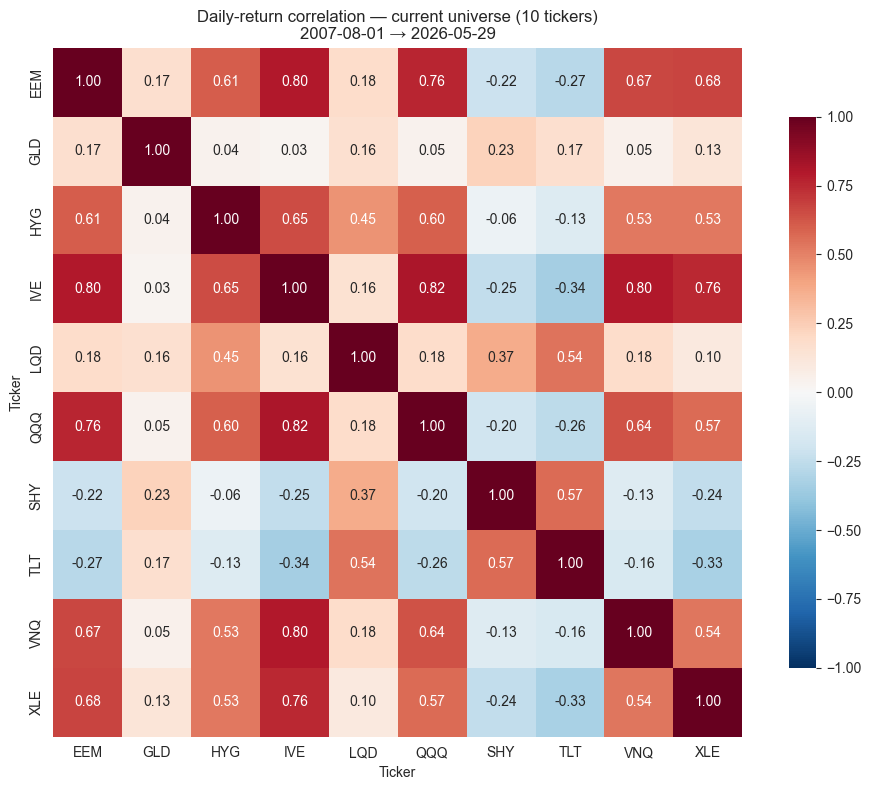

In [21]:
prices_cur = yf.download(
    CURRENT_TICKERS, start=str(TARGET_START.date()),
    auto_adjust=True, progress=False,
)["Close"].dropna()
rets_cur = prices_cur.pct_change().dropna()
corr_cur = rets_cur.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_cur, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={"shrink":0.8})
ax.set_title(f"Daily-return correlation — current universe ({len(CURRENT_TICKERS)} tickers)\n"
             f"{prices_cur.index[0].date()} → {prices_cur.index[-1].date()}")
plt.tight_layout()
plt.show()

In [22]:
THRESHOLD = 0.8
pairs = []
for i, t1 in enumerate(corr_cur.columns):
    for t2 in corr_cur.columns[i+1:]:
        c = corr_cur.loc[t1, t2]
        if c > THRESHOLD:
            pairs.append((t1, t2, c))
pairs = sorted(pairs, key=lambda x: -x[2])

print(f"Pairs with correlation > {THRESHOLD}:")
if pairs:
    for t1, t2, c in pairs:
        print(f"  {t1} <-> {t2}: {c:.3f}    ({ASSET_CLASS[t1]} / {ASSET_CLASS[t2]})")
else:
    print("  (none — universe is already free of strict redundancy)")

print("\nThe full table of off-diagonal correlations, ranked:")
off = corr_cur.where(np.triu(np.ones(corr_cur.shape), 1).astype(bool)).stack().sort_values(ascending=False)
print(off.head(10).to_string())

Pairs with correlation > 0.8:
  IVE <-> QQQ: 0.818    (US Large Value / US Large Growth)
  EEM <-> IVE: 0.801    (Emerging Markets Equity / US Large Value)
  IVE <-> VNQ: 0.801    (US Large Value / US Real Estate)

The full table of off-diagonal correlations, ranked:
Ticker  Ticker
IVE     QQQ      0.8180
EEM     IVE      0.8006
IVE     VNQ      0.8005
EEM     QQQ      0.7620
IVE     XLE      0.7564
EEM     XLE      0.6755
        VNQ      0.6656
HYG     IVE      0.6549
QQQ     VNQ      0.6378
EEM     HYG      0.6075


In [23]:
# Baseline diversification metrics for the current universe.
def participation_ratio(corr):
    """Effective number of independent assets via the correlation-eigenvalue PR."""
    e = np.linalg.eigvalsh(corr.values)
    return (e.sum() ** 2) / (e ** 2).sum()

avg_pairwise = (corr_cur.values.sum() - corr_cur.shape[0]) / (corr_cur.shape[0] * (corr_cur.shape[0] - 1))
xsec_std_cur = rets_cur.std(axis=1).mean()
effn_cur = participation_ratio(corr_cur)

print("=== Current universe — diversification scoreboard ===")
print(f"  Average pairwise correlation:               {avg_pairwise:.3f}")
print(f"  Mean daily cross-sectional return std:      {xsec_std_cur*100:.3f}%")
print(f"  Effective number of independent assets:     {effn_cur:.2f}  (of N={len(CURRENT_TICKERS)})")
print("\nReading: average corr ~0.30 is healthy; >0.60 indicates a one-factor universe.")
print("        Effective N << actual N means many assets are redundant.")

=== Current universe — diversification scoreboard ===
  Average pairwise correlation:               0.247
  Mean daily cross-sectional return std:      0.875%
  Effective number of independent assets:     3.67  (of N=10)

Reading: average corr ~0.30 is healthy; >0.60 indicates a one-factor universe.
        Effective N << actual N means many assets are redundant.


## 4. Marginal diversification contribution per candidate

For each qualifying candidate, simulate adding it to the current 10 and measure:
- **avg corr with current** — how decorrelated it is from what we already hold (lower is better),
- **delta xsec std** — the increase in mean cross-sectional return dispersion (higher = more allocation signal),
- **delta effective N** — the change in the effective number of independent assets (higher = more real diversification).

Rank candidates by `delta effective N`.

In [24]:
QUALIFIED = qualifying["ticker"].tolist()

all_prices = yf.download(
    CURRENT_TICKERS + QUALIFIED, start=str(TARGET_START.date()),
    auto_adjust=True, progress=False,
)["Close"].dropna(how="any")
all_rets = all_prices.pct_change().dropna()

# Restate the current-universe baseline on the common window so it's apples-to-apples.
cur_rets_aligned = all_rets[CURRENT_TICKERS]
cur_corr_aligned = cur_rets_aligned.corr()
cur_xsec_aligned = cur_rets_aligned.std(axis=1).mean()
cur_effn_aligned = participation_ratio(cur_corr_aligned)

results = []
for cand in QUALIFIED:
    sub = all_rets[CURRENT_TICKERS + [cand]]
    new_corr = sub.corr()
    new_xsec = sub.std(axis=1).mean()
    new_effn = participation_ratio(new_corr)
    avg_corr_cur = new_corr.loc[cand, CURRENT_TICKERS].mean()
    max_abs_corr_cur = new_corr.loc[cand, CURRENT_TICKERS].abs().max()
    results.append({
        "candidate":            cand,
        "asset_class":          ASSET_CLASS.get(cand, "?"),
        "avg_corr_w_current":   avg_corr_cur,
        "max|corr|_w_current":  max_abs_corr_cur,
        "new_xsec_std_%":       new_xsec * 100,
        "delta_xsec_std_pp":    (new_xsec - cur_xsec_aligned) * 100,
        "new_effective_N":      new_effn,
        "delta_effective_N":    new_effn - cur_effn_aligned,
    })

marginal = pd.DataFrame(results).sort_values("delta_effective_N", ascending=False).reset_index(drop=True)
marginal

,candidate,asset_class,avg_corr_w_current,max|corr|_w_current,new_xsec_std_%,delta_xsec_std_pp,new_effective_N,delta_effective_N
0,UUP,US Dollar Bullish,-0.2121,0.4221,0.8717,-0.0033,4.1310,0.4592
1,FXE,Euro,0.2089,0.3747,0.8540,-0.0211,4.1300,0.4582
2,DBA,Agricultural Commodities,0.1722,0.3615,0.8837,0.0086,4.1151,0.4434
3,FXY,Japanese Yen,0.0001,0.4870,0.8681,-0.0069,4.0280,0.3563
4,SLV,Silver,0.2399,0.7885,0.9641,0.0890,4.0120,0.3403
5,USO,Crude Oil,0.1900,0.6292,1.0015,0.1264,4.0098,0.3380
6,GDX,Gold Miners (Equity + Gold beta),0.2777,0.7625,1.0314,0.1564,3.9768,0.3050
7,TIP,Inflation-Linked Treasuries,0.1758,0.7002,0.8500,-0.0251,3.9396,0.2678
8,DBC,Broad Commodities,0.2497,0.6514,0.8819,0.0068,3.9276,0.2558
9,PFF,Preferred Stock,0.3441,0.6174,0.8524,-0.0226,3.7711,0.0993


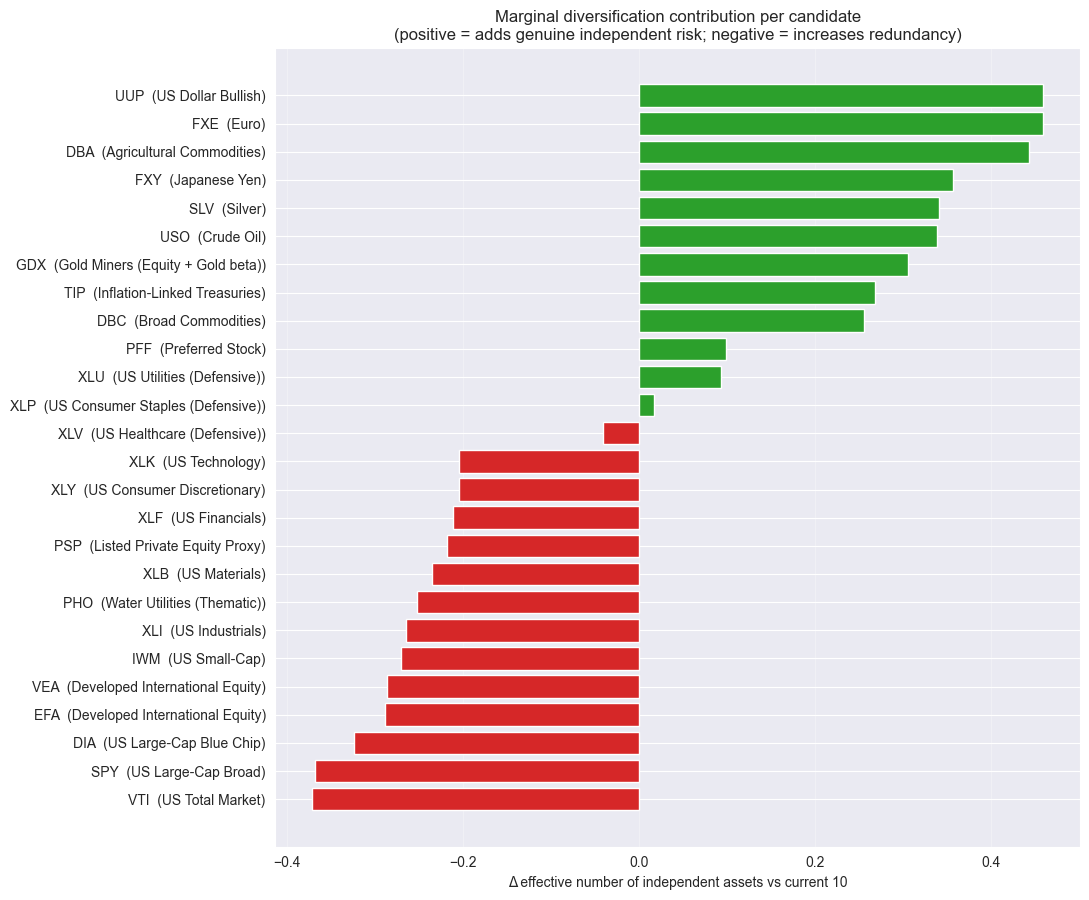

In [25]:
# Plot delta_effective_N for an at-a-glance ranking.
fig, ax = plt.subplots(figsize=(11, max(4, 0.35*len(marginal))))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in marginal["delta_effective_N"]]
ax.barh(marginal["candidate"] + "  (" + marginal["asset_class"] + ")", marginal["delta_effective_N"], color=colors)
ax.set_xlabel("Δ effective number of independent assets vs current 10")
ax.set_title("Marginal diversification contribution per candidate\n(positive = adds genuine independent risk; negative = increases redundancy)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Asset-class coverage map

Which asset classes are **already represented** in the current 10, and which are **missing** but available among qualifying candidates.

In [26]:
current_classes = {ASSET_CLASS[t] for t in CURRENT_TICKERS}
candidate_classes = {ASSET_CLASS[t] for t in QUALIFIED}
missing_classes = sorted(candidate_classes - current_classes)
covered_classes = sorted(current_classes)

print(f"COVERED ({len(covered_classes)} classes):")
for c in covered_classes: print(f"  ✓  {c}")
print(f"\nMISSING but available ({len(missing_classes)} classes):")
for c in missing_classes:
    candidates_for_class = [t for t in QUALIFIED if ASSET_CLASS[t] == c]
    print(f"  +  {c:35s}  candidates: {', '.join(candidates_for_class)}")

COVERED (10 classes):
  ✓  Emerging Markets Equity
  ✓  Gold
  ✓  High Yield Credit
  ✓  Investment Grade Credit
  ✓  US Energy Sector
  ✓  US Large Growth
  ✓  US Large Value
  ✓  US Long Treasuries
  ✓  US Real Estate
  ✓  US Short Treasuries

MISSING but available (25 classes):
  +  Agricultural Commodities             candidates: DBA
  +  Broad Commodities                    candidates: DBC
  +  Crude Oil                            candidates: USO
  +  Developed International Equity       candidates: EFA, VEA
  +  Euro                                 candidates: FXE
  +  Gold Miners (Equity + Gold beta)     candidates: GDX
  +  Inflation-Linked Treasuries          candidates: TIP
  +  Japanese Yen                         candidates: FXY
  +  Listed Private Equity Proxy          candidates: PSP
  +  Preferred Stock                      candidates: PFF
  +  Silver                               candidates: SLV
  +  US Consumer Discretionary            candidates: XLY
  +  US Consumer 

## 6. Build a proposed universe and inspect it

Edit `PROPOSED_ADDITIONS` and `PROPOSED_DROPS` below to test any universe you want. The cell shows the resulting correlation heatmap and diversification scoreboard.

Proposed universe (13): ['IVE', 'QQQ', 'TLT', 'SHY', 'LQD', 'HYG', 'GLD', 'EEM', 'VNQ', 'XLE', 'EFA', 'DBC', 'TIP']


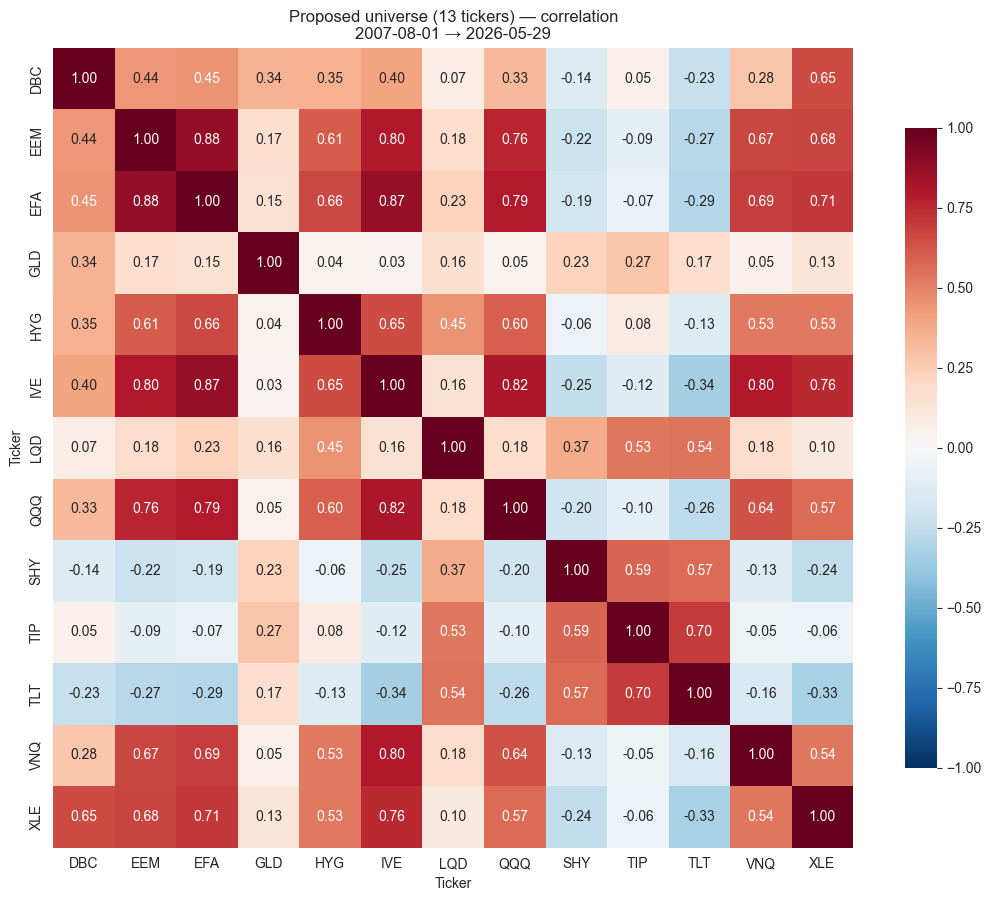

=== Proposed universe — diversification scoreboard ===
  Average pairwise correlation:           0.260   (current: 0.247)
  Mean daily xsec return std:             0.846%   (current: 0.875%)
  Effective number of independent assets: 3.91    (current: 3.67)


In [27]:
# === Edit these two lists to test your candidate universe ===
PROPOSED_ADDITIONS = ["EFA", "DBC", "TIP"]   # e.g., developed-intl + broad commodities + inflation bonds
PROPOSED_DROPS     = []                       # e.g., ["LQD"] if a pair > 0.85 says it's redundant
# ===========================================================

proposed = [t for t in CURRENT_TICKERS if t not in PROPOSED_DROPS] + PROPOSED_ADDITIONS
print(f"Proposed universe ({len(proposed)}): {proposed}")

px = yf.download(proposed, start=str(TARGET_START.date()),
                 auto_adjust=True, progress=False)["Close"].dropna()
rt = px.pct_change().dropna()
co = rt.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(co, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            ax=ax, square=True, cbar_kws={"shrink":0.8})
ax.set_title(f"Proposed universe ({len(proposed)} tickers) — correlation\n"
             f"{px.index[0].date()} → {px.index[-1].date()}")
plt.tight_layout()
plt.show()

avg_p = (co.values.sum() - co.shape[0]) / (co.shape[0]*(co.shape[0]-1))
xsec_p = rt.std(axis=1).mean()
effn_p = participation_ratio(co)
print("=== Proposed universe — diversification scoreboard ===")
print(f"  Average pairwise correlation:           {avg_p:.3f}   (current: {avg_pairwise:.3f})")
print(f"  Mean daily xsec return std:             {xsec_p*100:.3f}%   (current: {xsec_std_cur*100:.3f}%)")
print(f"  Effective number of independent assets: {effn_p:.2f}    (current: {effn_cur:.2f})")

## 7. Summary & decision rules

**What to add** (in priority order):
1. Anything in the **MISSING classes** list above that *qualifies* for 2007-05-01.
2. Among ties, prefer the candidate with the **lowest `avg_corr_w_current`** in the marginal table (most decorrelated from what you already hold).
3. Among further ties, prefer the higher **`delta_effective_N`**.

**What to drop:**
- Any pair from the `corr > 0.85` list, **dropping the weaker name** (e.g. lower historical Sharpe).
- **Never drop CASH or SHY.** The earlier sweep proved the turbulence cash gate is your entire edge over EqualWeight (Sharpe 0.94 with gate vs 0.70 without). Removing the defensive end of the universe would destroy it.

**What this won't fix.** The structural collapse-to-equal-weight comes from low daily signal-to-noise on US-correlated assets; better universe diversity reduces it but won't eliminate it. Kashif & Slepaczuk (2025) saw the same residual flatness even with cross-country global equity diversification. Realistic expectation: **moving Sharpe from ~0.77 toward 0.80–0.85** with a well-chosen addition, not a breakthrough. The structural ceiling lives elsewhere (selection, intraday frequency, predictive features), not in the universe.

**Workflow after editing the universe in `config.json`:**
1. Re-run stage 1 (data download) — `python 01_get_data.py`.
2. Re-run the experiment runner — `python run_experiments.py --experiments experiments.json --force` (force because old results are now stale).
3. Compare new ranked table to the existing one (`enc_hidden128_emb_dim1` Sharpe = 0.774 / bt 0.782 / EqualWeight 0.784).

### Academic references
- **Markowitz, H. (1952).** *Portfolio Selection.* J. Finance — marginal Sharpe of a new asset shrinks toward zero with correlation; canonical justification for adding decorrelated assets and removing duplicates.
- **Moody, J. & Saffell, M. (2001).** *Learning to Trade via Direct Reinforcement.* IEEE TNN — small (2–3 asset) universe with strong cross-dynamics produces active RL policies; foundational for the `diff_sharpe` reward.
- **Jiang, Z., Xu, D., & Liang, J. (2017).** *A Deep RL Framework for the Financial Portfolio Management Problem.* arXiv:1706.10059 — EIIE architecture; explicitly chose 12 cryptocurrencies for *extreme* cross-sectional dispersion. Same architecture on tightly-correlated equities behaves more flatly.
- **Liang, Z. et al. (2018).** *Adversarial Deep RL in Portfolio Management.* arXiv:1808.09940 — PG/PPO/DDPG on Chinese equities; reports performance improves with more decorrelated asset classes (adding gold and bonds to equity baskets).
- **Yang, H., Liu, X., Zhong, S., & Walid, A. (2020).** *Deep RL for Automated Stock Trading: An Ensemble Strategy.* ICAIF — DOW 30 (tightly-correlated US large caps); ensemble of three algorithms was needed to compensate for noisy, low-dispersion signal.
- **Kashif, A. & Slepaczuk, R. (2025).** *Deep RL Framework for Diversified Portfolio Management Across Global Equity Markets.* arXiv:2605.17307 — global indices chosen explicitly *because* single-market sector ETFs gave too little dispersion. Policy was still close to uniform on many days, but materially less collapsed than single-market sector baskets. **This is your most directly comparable benchmark.**